In [212]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("india_housing_prices.csv")

In [213]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [214]:
df.shape

(250000, 23)

In [215]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [216]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [217]:
df.duplicated().sum()

np.int64(0)

In [218]:
df.drop_duplicates(inplace=True)

In [219]:
mask = df["Floor_No"] > df["Total_Floors"]

df.loc[mask, ["Floor_No", "Total_Floors"]] = (
    df.loc[mask, ["Total_Floors", "Floor_No"]].values
)

In [220]:
df["Price_per_SqFt"] = (
    df["Price_in_Lakhs"] * 100000
) / df["Size_in_SqFt"]

In [221]:
df["Future_Price_5Y"] = (
    df["Price_in_Lakhs"] * (1.08 ** 5)
)

In [222]:
# =========================================================
# FEATURE ENGINEERING
# =========================================================

# Price per SqFt
df["Price_per_SqFt"] = (
    df["Price_in_Lakhs"] * 100000
) / df["Size_in_SqFt"]


# Transport Score
transport_map = {
    "Low": 0,
    "Medium": 1,
    "High": 2
}

df["Transport_Score"] = df[
    "Public_Transport_Accessibility"
].map(transport_map)


# Amenities Count
df["Amenities_Count"] = df[
    "Amenities"
].apply(
    lambda x: len(str(x).split(","))
)


# City Median Price per SqFt
city_median_pps = df.groupby(
    "City"
)["Price_per_SqFt"].transform("median")


# Price Value Score
df["Price_Value_Score"] = (
    df["Price_per_SqFt"] < city_median_pps
).astype(int)

In [223]:
# =========================================================
# TARGET VARIABLE
# =========================================================

df["Investment_Score"] = 0


# Cheap compared to city average
df["Investment_Score"] += (
    df["Price_Value_Score"]
)


# Good BHK
df["Investment_Score"] += (
    (df["BHK"] >= 3).astype(int)
)


# Good transport
df["Investment_Score"] += (
    (df["Transport_Score"] >= 1).astype(int)
)


# Final Target
df["Good_Investment"] = (
    df["Investment_Score"] >= 2
).astype(int)


# Check balance
print(
    df["Good_Investment"].value_counts()
)

print(
    df["Good_Investment"]
    .value_counts(normalize=True) * 100
)


Good_Investment
1    158316
0     91684
Name: count, dtype: int64
Good_Investment
1    63.3264
0    36.6736
Name: proportion, dtype: float64


In [224]:
df["Good_Investment"].value_counts()

Good_Investment
1    158316
0     91684
Name: count, dtype: int64

In [225]:
df["Good_Investment"].value_counts(normalize=True) * 100

Good_Investment
1    63.3264
0    36.6736
Name: proportion, dtype: float64

# EDA

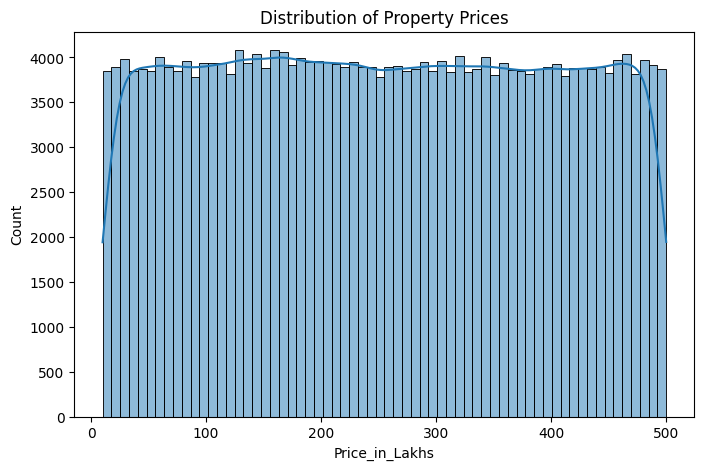

In [226]:
#1.
plt.figure(figsize=(8,5))

sns.histplot(df["Price_in_Lakhs"], kde=True)

plt.title("Distribution of Property Prices")

plt.show()

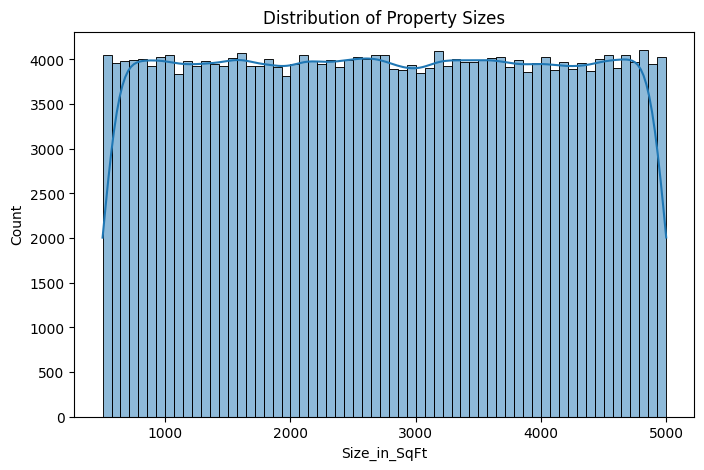

In [227]:
#2
plt.figure(figsize=(8,5))

sns.histplot(df["Size_in_SqFt"], kde=True)

plt.title("Distribution of Property Sizes")

plt.show()

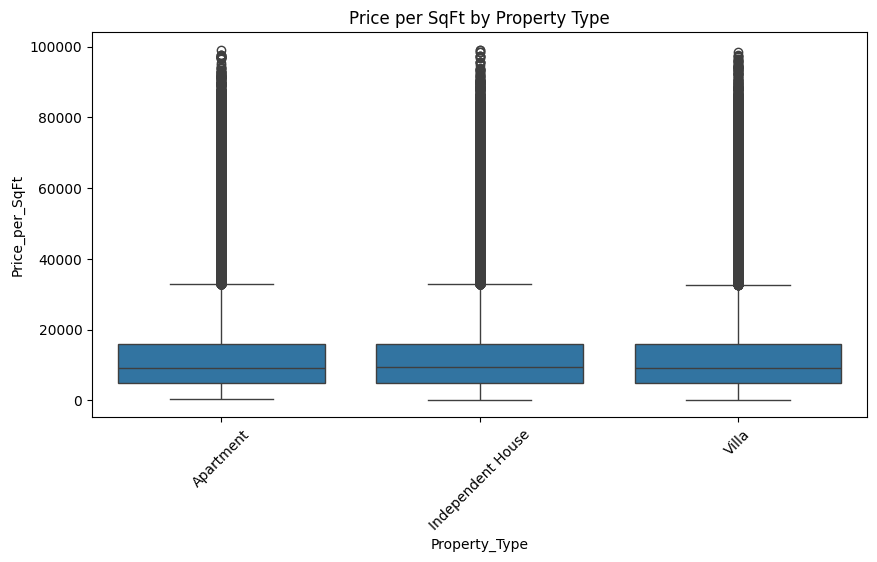

In [228]:
#3
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Property_Type",
    y="Price_per_SqFt",
    data=df
)

plt.xticks(rotation=45)

plt.title("Price per SqFt by Property Type")

plt.show()

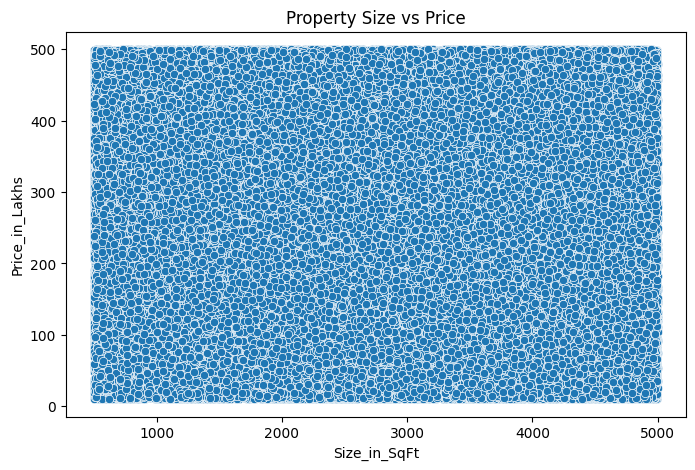

In [229]:
#4
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Size_in_SqFt",
    y="Price_in_Lakhs",
    data=df
)

plt.title("Property Size vs Price")

plt.show()

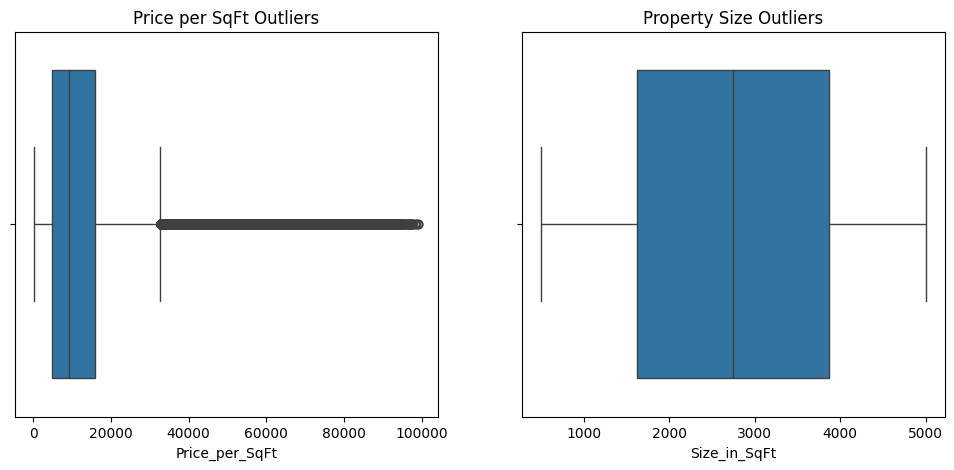

In [230]:
#5
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(x=df["Price_per_SqFt"], ax=ax[0])

sns.boxplot(x=df["Size_in_SqFt"], ax=ax[1])

ax[0].set_title("Price per SqFt Outliers")

ax[1].set_title("Property Size Outliers")

plt.show()

Location based

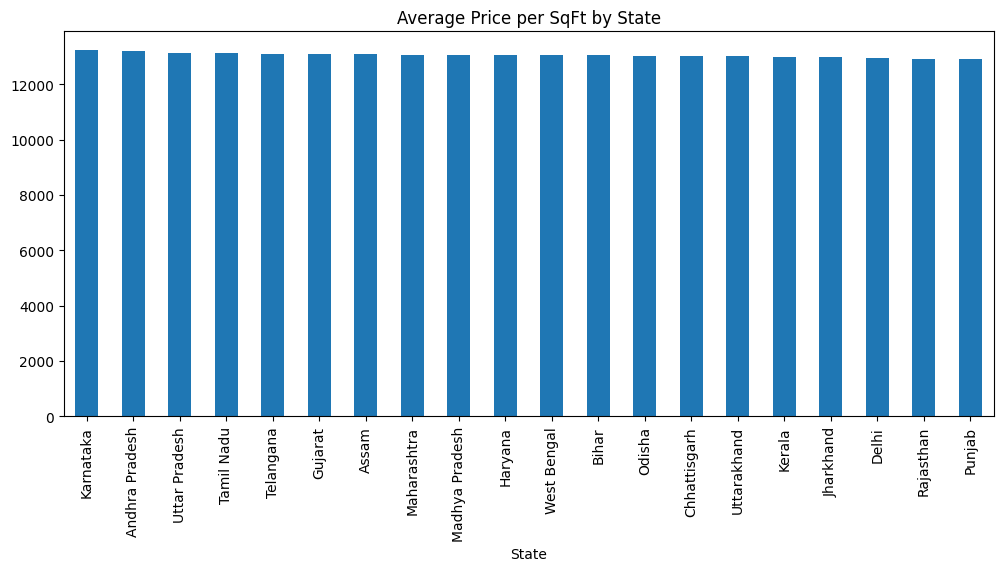

In [231]:
#6
state_price = (
    df.groupby("State")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,5))

state_price.plot(kind="bar")

plt.title("Average Price per SqFt by State")

plt.show()

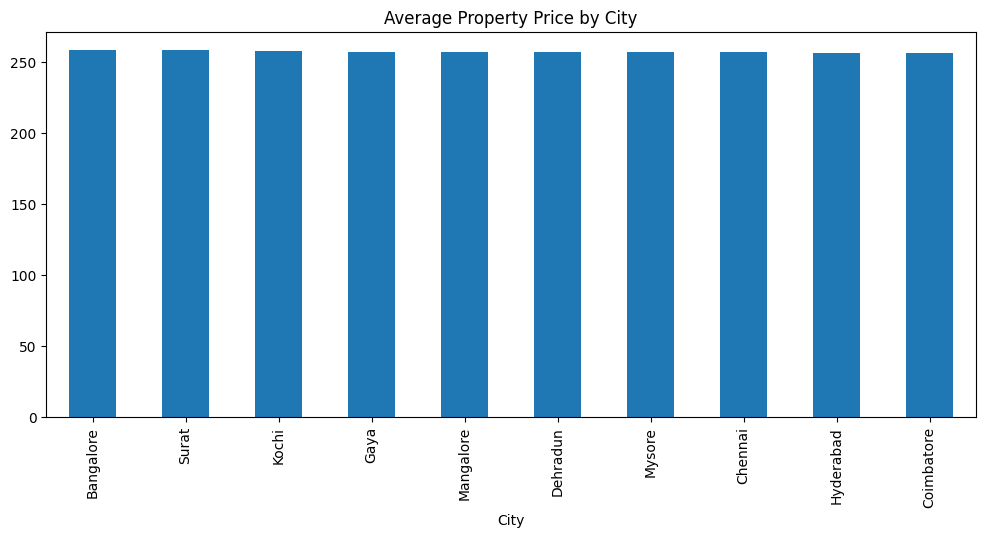

In [232]:
#7
city_price = (
    df.groupby("City")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

city_price.plot(kind="bar")

plt.title("Average Property Price by City")

plt.show()

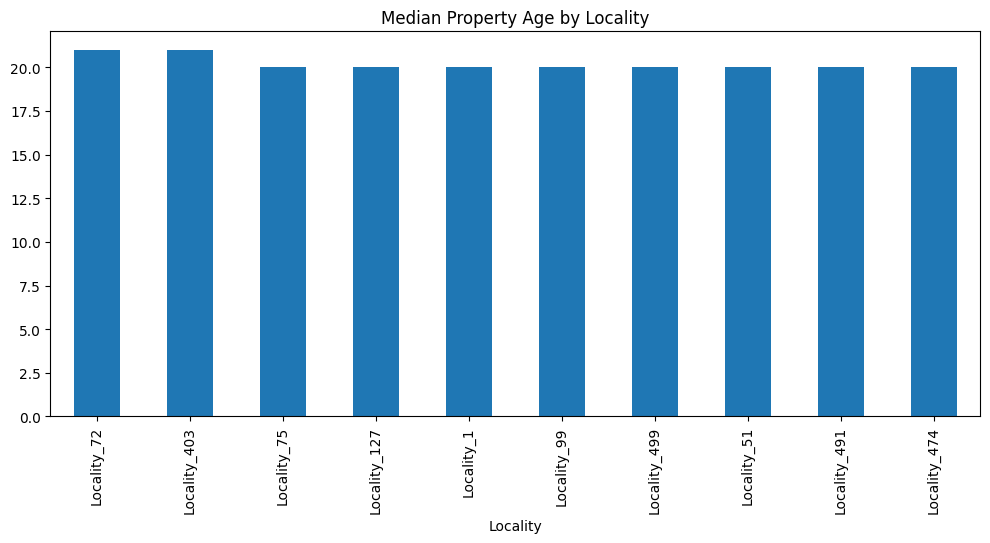

In [233]:
#8
locality_age = (
    df.groupby("Locality")["Age_of_Property"]
    .median()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

locality_age.plot(kind="bar")

plt.title("Median Property Age by Locality")

plt.show()

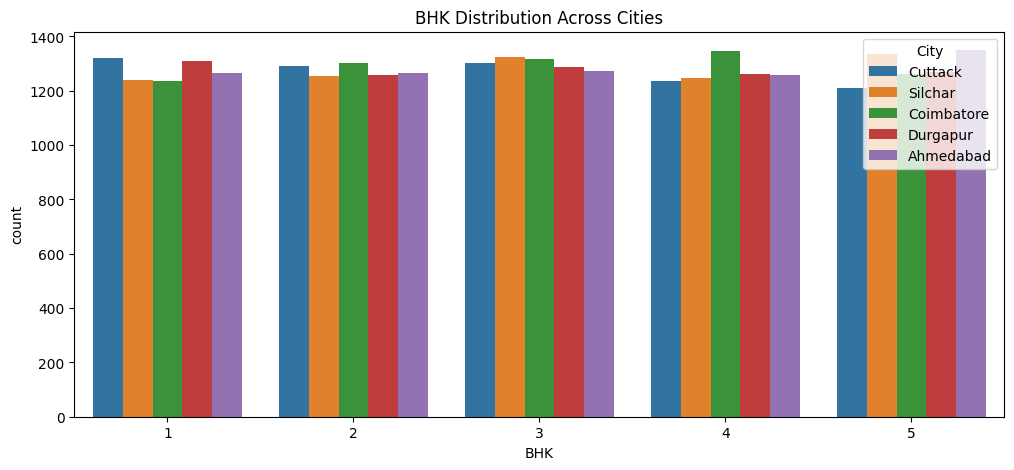

In [234]:
#9
plt.figure(figsize=(12,5))

sns.countplot(
    x="BHK",
    hue="City",
    data=df[df["City"].isin(df["City"].value_counts().head(5).index)]
)

plt.title("BHK Distribution Across Cities")

plt.show()

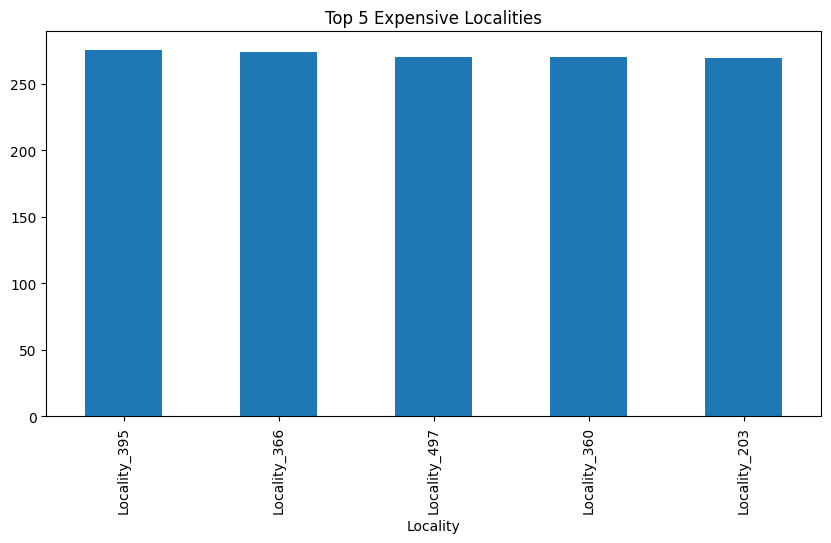

In [235]:
#10
top_localities = (
    df.groupby("Locality")["Price_in_Lakhs"]
    .mean()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(10,5))

top_localities.plot(kind="bar")

plt.title("Top 5 Expensive Localities")

plt.show()

In [236]:
df.to_csv("cleaned.csv", index=False)

Rel & Col

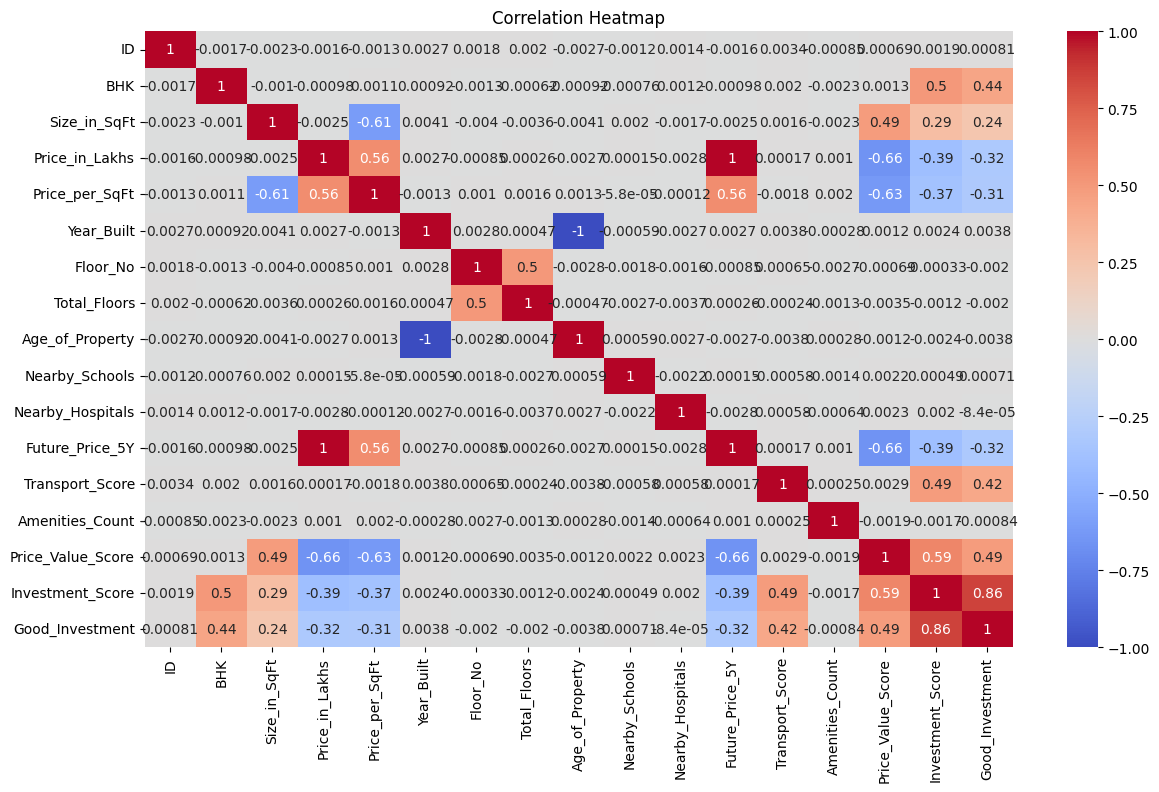

In [237]:
#11
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(14,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

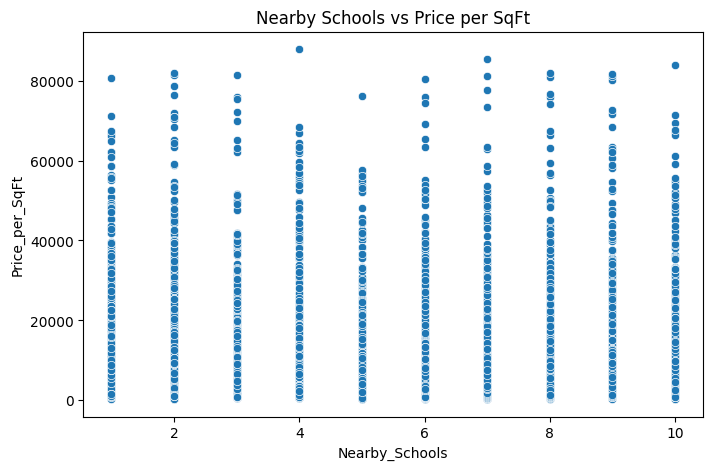

In [238]:
#12
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Nearby_Schools",
    y="Price_per_SqFt",
    data=df.sample(5000)
)

plt.title("Nearby Schools vs Price per SqFt")

plt.show()

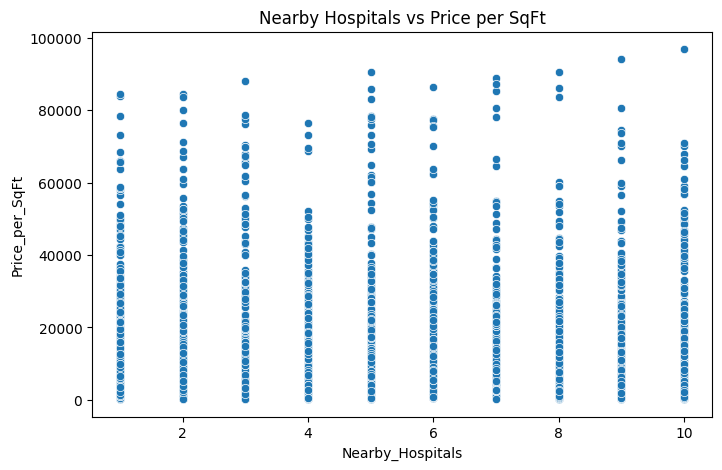

In [239]:
#13
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Nearby_Hospitals",
    y="Price_per_SqFt",
    data=df.sample(5000)
)

plt.title("Nearby Hospitals vs Price per SqFt")

plt.show()

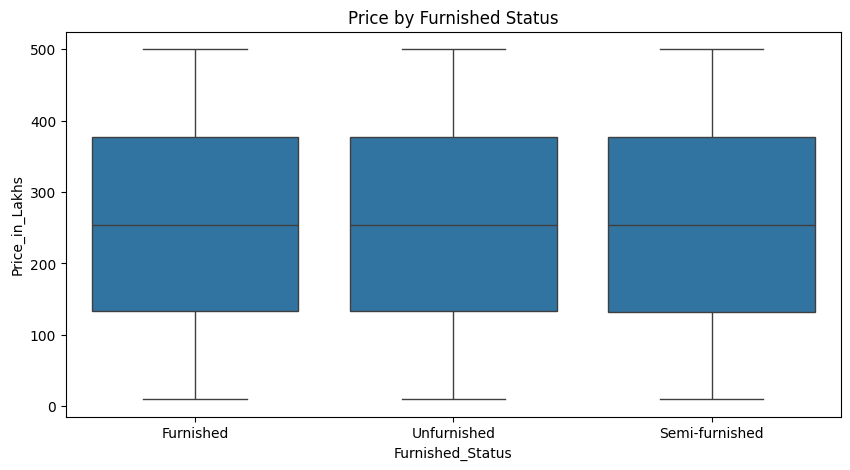

In [240]:
#14
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Furnished_Status",
    y="Price_in_Lakhs",
    data=df
)

plt.title("Price by Furnished Status")

plt.show()

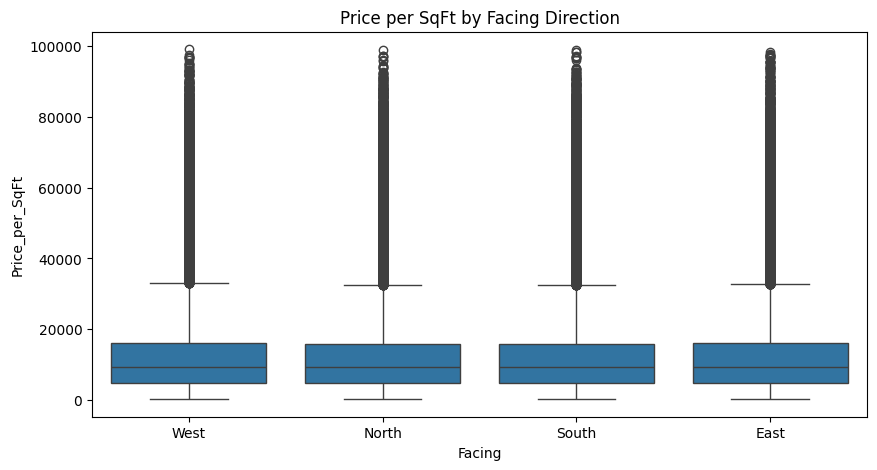

In [241]:
#15
plt.figure(figsize=(10,5))

sns.boxplot(
    x="Facing",
    y="Price_per_SqFt",
    data=df
)

plt.title("Price per SqFt by Facing Direction")

plt.show()

Investment / Amenities / Ownership Analysis

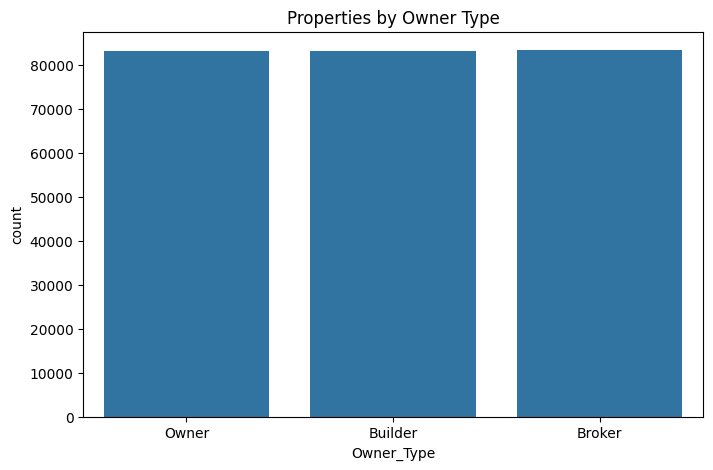

In [242]:
#16
plt.figure(figsize=(8,5))

sns.countplot(
    x="Owner_Type",
    data=df
)

plt.title("Properties by Owner Type")

plt.show()

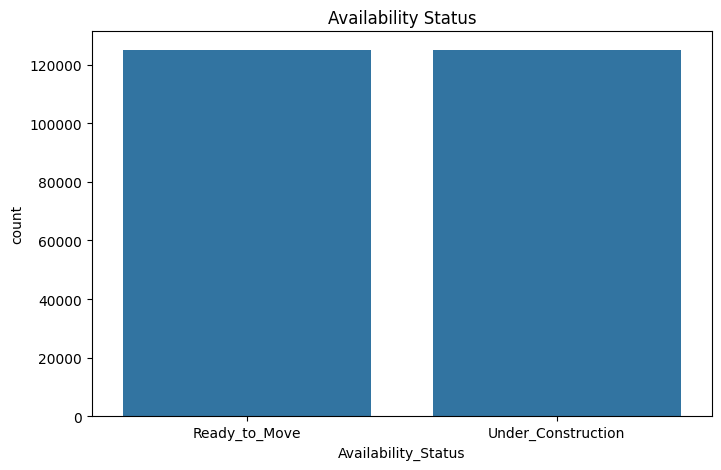

In [243]:
#17
plt.figure(figsize=(8,5))

sns.countplot(
    x="Availability_Status",
    data=df
)

plt.title("Availability Status")

plt.show()

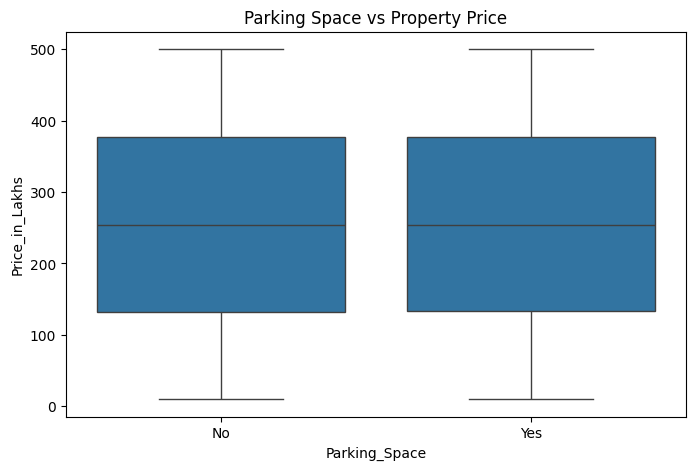

In [244]:
#18
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Parking_Space",
    y="Price_in_Lakhs",
    data=df
)

plt.title("Parking Space vs Property Price")

plt.show()

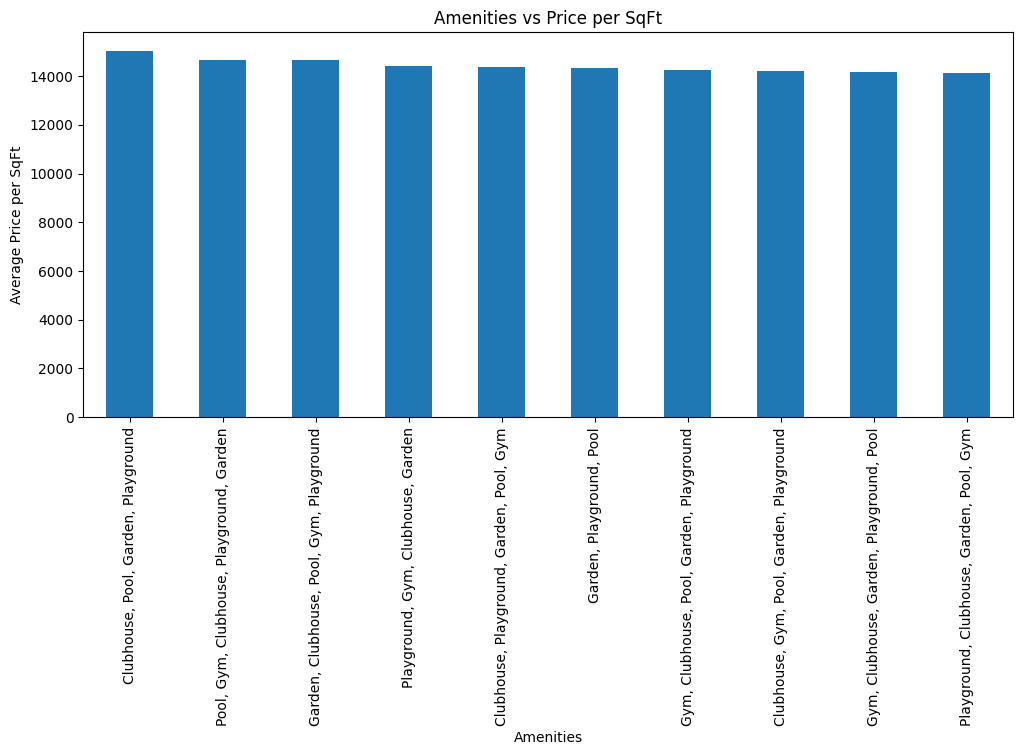

In [245]:
#19

amenity_price = (
    df.groupby("Amenities")["Price_per_SqFt"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,5))

amenity_price.plot(kind="bar")

plt.title("Amenities vs Price per SqFt")

plt.ylabel("Average Price per SqFt")

plt.show()


# Observation:
# Premium amenities increase property value.

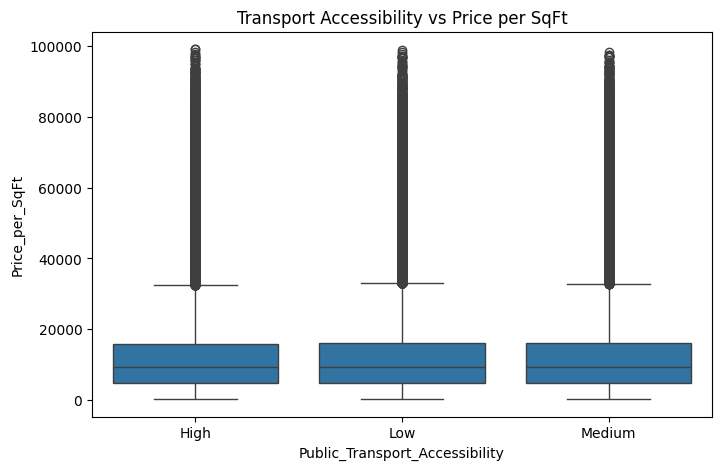

In [246]:
#20
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Public_Transport_Accessibility",
    y="Price_per_SqFt",
    data=df
)

plt.title("Transport Accessibility vs Price per SqFt")

plt.show()

In [247]:
df.to_csv("cleaned.csv", index=False)